<a href="https://colab.research.google.com/github/koustav241013006127tiu/AI-Python/blob/main/labproblem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Minimum sequence of steps:

0 : (0, 0)
1 : (0, 3)
2 : (3, 0)
3 : (3, 3)
4 : (4, 2)


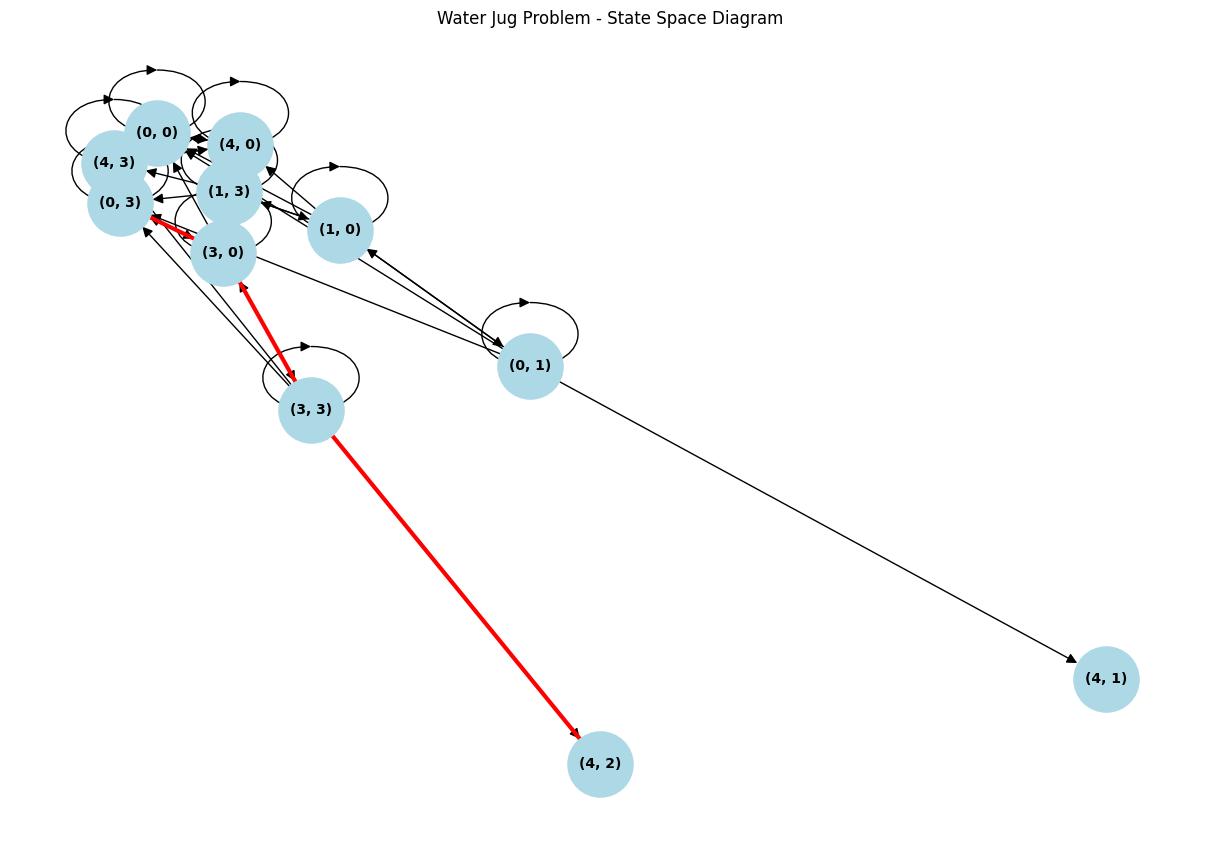

In [1]:
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt


def water_jug():
    capacity_a = 4
    capacity_b = 3
    target = 2

    start = (0, 0)

    queue = deque([(start, [])])
    visited = set()

    # Store all state transitions for the diagram
    graph = {}

    while queue:
        (a, b), path = queue.popleft()

        if (a, b) in visited:
            continue

        visited.add((a, b))
        path = path + [(a, b)]

        # Check target
        if a == target or b == target:
            print("Minimum sequence of steps:\n")

            for i, state in enumerate(path):
                print(f"{i} : {state}")

            # Draw state-space diagram
            G = nx.DiGraph()

            for state in graph:
                for next_state in graph[state]:
                    G.add_edge(state, next_state)

            # Add states from solution path
            for state in path:
                G.add_node(state)

            # Position nodes automatically
            pos = nx.spring_layout(G, seed=42)

            plt.figure(figsize=(12, 8))

            # Draw all nodes and edges
            nx.draw(
                G,
                pos,
                with_labels=True,
                node_size=2200,
                node_color="lightblue",
                font_size=10,
                font_weight="bold",
                arrows=True,
                arrowsize=15
            )

            # Highlight solution path
            solution_edges = [
                (path[i], path[i + 1])
                for i in range(len(path) - 1)
            ]

            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=solution_edges,
                edge_color="red",
                width=3,
                arrows=True,
                arrowsize=20
            )

            plt.title("Water Jug Problem - State Space Diagram")
            plt.axis("off")
            plt.show()

            return

        states = []

        # Fill Jug A
        states.append((capacity_a, b))

        # Fill Jug B
        states.append((a, capacity_b))

        # Empty Jug A
        states.append((0, b))

        # Empty Jug B
        states.append((a, 0))

        # Pour A -> B
        amount = min(a, capacity_b - b)
        states.append((a - amount, b + amount))

        # Pour B -> A
        amount = min(b, capacity_a - a)
        states.append((a + amount, b - amount))

        # Store transitions
        graph[(a, b)] = states

        # Add states to queue
        for state in states:
            if state not in visited:
                queue.append((state, path))


# Run the program
water_jug()